<a href="https://colab.research.google.com/github/HitanshVit/Paytm-ai-Project-Hitansh-Sondhi/blob/main/pnemonia_detection_using_EfficientNetV2B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
paultimothymooney_chest_xray_pneumonia_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')

print('Data source import complete.')


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Data source import complete.


In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler

import seaborn as sns

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [ ]:
try:
    resolver = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(resolver)
    tf.tpu.experimental.initialize_tpu_system(resolver)
    strategy = tf.distribute.TPUStrategy(resolver)
    print("TPU initialized")
except:
    strategy = tf.distribute.get_strategy()
    print("Running on CPU/GPU")

print("Replicas:", strategy.num_replicas_in_sync)

Running on CPU/GPU
Replicas: 1


In [ ]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [ ]:
DATA_PATH = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

paths = []
labels = []

for split in ["train","test","val"]:

    normal_dir = os.path.join(DATA_PATH, split, "NORMAL")
    pneu_dir = os.path.join(DATA_PATH, split, "PNEUMONIA")

    for img in os.listdir(normal_dir):
        paths.append(os.path.join(normal_dir,img))
        labels.append(0)

    for img in os.listdir(pneu_dir):
        paths.append(os.path.join(pneu_dir,img))
        labels.append(1)

df = pd.DataFrame({
    "path":paths,
    "label":labels
})

print("Total images:", len(df))
df.head()

Total images: 5856


,path,label
0,/kaggle/input/datasets/paultimothymooney/chest...,0
1,/kaggle/input/datasets/paultimothymooney/chest...,0
2,/kaggle/input/datasets/paultimothymooney/chest...,0
3,/kaggle/input/datasets/paultimothymooney/chest...,0
4,/kaggle/input/datasets/paultimothymooney/chest...,0


In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df.label,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df.label,
    random_state=42
)

print(len(train_df), len(val_df), len(test_df))

4099 878 879


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 64 * strategy.num_replicas_in_sync

def preprocess_image(path, label):

    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    img = tf.cast(img, tf.float32) / 255.0

    label = tf.cast(label, tf.float32)

    return img, label

In [ ]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),

])

In [ ]:
def create_dataset(df, training=False):

    paths = df.path.values
    labels = df.label.values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    ds = ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

    def create_targets(img, label):

        pneumonia = tf.expand_dims(label, axis=-1)

        concepts = tf.repeat(pneumonia, 6, axis=-1)

        return img, {
            "pneumonia": pneumonia,
            "concepts": concepts
        }

    ds = ds.map(create_targets, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.map(lambda x,y: (data_augmentation(x),y),
                    num_parallel_calls=tf.data.AUTOTUNE)

        ds = ds.shuffle(2048)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

In [ ]:
train_ds = create_dataset(train_df, True)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df.label),
    y=train_df.label
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.8497292418772564), 1: np.float64(0.6852223336676697)}


In [ ]:
def focal_loss(gamma=2., alpha=.25):

    def loss(y_true, y_pred):

        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        pt = tf.exp(-bce)

        focal = alpha * (1-pt)**gamma * bce

        return tf.reduce_mean(focal)

    return loss

In [ ]:
def rule_loss(concepts, pneumonia_prob):

    c1,c2,c3,c4,c5,c6 = tf.split(concepts,6,axis=1)

    rule1 = tf.maximum(c1,c2)
    rule2 = c5
    rule3 = c4
    rule4 = c3
    rule5 = c6

    expected = tf.maximum(rule1,
                 tf.maximum(rule2,
                 tf.maximum(rule3,
                 tf.maximum(rule4,rule5))))

    return tf.reduce_mean(tf.square(pneumonia_prob - expected))

In [ ]:
with strategy.scope():

    backbone = EfficientNetV2B0(
        include_top=False,
        weights="imagenet",
        input_shape=(224,224,3)
    )

    x = backbone.output
    x = layers.GlobalAveragePooling2D()(x)

    attention = layers.Dense(512, activation="relu")(x)

    embedding = layers.Dense(256, activation="relu")(attention)

    concepts = layers.Dense(6, activation="sigmoid", name="concepts")(embedding)

    pneumonia = layers.Dense(1, activation="sigmoid", name="pneumonia")(concepts)

    model = tf.keras.Model(backbone.input, [pneumonia, concepts])

    model.build((None,224,224,3))

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss={
        "pneumonia": focal_loss(),
        "concepts": "binary_crossentropy"
    },
    loss_weights={
        "pneumonia":1.0,
        "concepts":0.3
    },
    metrics={
        "pneumonia":["accuracy"]
    }
)

In [ ]:
def cosine_lr(epoch):

    initial = 1e-4
    return initial * (1 + np.cos(np.pi * epoch / 20)) / 2

In [ ]:
callbacks = [

    EarlyStopping(
        patience=5,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        "pneumonia_model.h5",
        save_best_only=True
    ),

    LearningRateScheduler(cosine_lr)

]


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20


I0000 00:00:1772615818.871239     150 service.cc:152] XLA service 0x79236c0045e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772615818.871281     150 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772615818.871286     150 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772615828.031587     150 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-04 09:17:36.376997: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bw-filter.66 = (f16[16,3,3,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[64,112,112,32]{3,2,1,0} %bitcast.128862, f16[64,112,112,16]{3,2,1,0} %bitcast.128864), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", metadata={op_type="Conv2DBackpropFilter" op_name="gradient_tape/functional_3_1/block1a_project_conv_1/convolution/Conv2DB

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - concepts_loss: 0.5032 - loss: 0.1890 - pneumonia_accuracy: 0.7739 - pneumonia_loss: 0.0380   

65/65 ━━━━━━━━━━━━━━━━━━━━ 362s 3s/step - concepts_loss: 0.5013 - loss: 0.1884 - pneumonia_accuracy: 0.7748 - pneumonia_loss: 0.0380 - val_concepts_loss: 0.6124 - val_loss: 0.2199 - val_pneumonia_accuracy: 0.7312 - val_pneumonia_loss: 0.0366 - learning_rate: 1.0000e-04
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 46s 412ms/step - concepts_loss: 0.2015 - loss: 0.0965 - pneumonia_accuracy: 0.9259 - pneumonia_loss: 0.0361 - val_concepts_loss: 0.6495 - val_loss: 0.2331 - val_pneumonia_accuracy: 0.7301 - val_pneumonia_loss: 0.0381 - learning_rate: 9.9384e-05
Epoch 3/20
64/65 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - concepts_loss: 0.1888 - loss: 0.0919 - pneumonia_accuracy: 0.9400 - pneumonia_loss: 0.0353

65/65 ━━━━━━━━━━━━━━━━━━━━ 47s 429ms/step - concepts_loss: 0.1882 - loss: 0.0918 - pneumonia_accuracy: 0.9401 - pneumonia_loss: 0.0353 - val_concepts_loss: 0.2108 - val_loss: 0.0950 - val_pneumonia_accuracy: 0.9100 - val_pneumonia_loss: 0.0320 - learning_rate: 9.7553e-05
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 46s 413ms/step - concepts_loss: 0.1508 - loss: 0.0796 - pneumonia_accuracy: 0.9518 - pneumonia_loss: 0.0344 - val_concepts_loss: 0.2268 - val_loss: 0.0979 - val_pneumonia_accuracy: 0.9146 - val_pneumonia_loss: 0.0304 - learning_rate: 9.4550e-05
Epoch 5/20
64/65 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - concepts_loss: 0.1229 - loss: 0.0708 - pneumonia_accuracy: 0.9529 - pneumonia_loss: 0.0340

65/65 ━━━━━━━━━━━━━━━━━━━━ 48s 435ms/step - concepts_loss: 0.1228 - loss: 0.0708 - pneumonia_accuracy: 0.9530 - pneumonia_loss: 0.0340 - val_concepts_loss: 0.1580 - val_loss: 0.0774 - val_pneumonia_accuracy: 0.9544 - val_pneumonia_loss: 0.0302 - learning_rate: 9.0451e-05
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 46s 417ms/step - concepts_loss: 0.1379 - loss: 0.0740 - pneumonia_accuracy: 0.9533 - pneumonia_loss: 0.0331 - val_concepts_loss: 0.1659 - val_loss: 0.0814 - val_pneumonia_accuracy: 0.9248 - val_pneumonia_loss: 0.0320 - learning_rate: 8.5355e-05
Epoch 7/20
64/65 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - concepts_loss: 0.1173 - loss: 0.0673 - pneumonia_accuracy: 0.9555 - pneumonia_loss: 0.0322

65/65 ━━━━━━━━━━━━━━━━━━━━ 47s 431ms/step - concepts_loss: 0.1171 - loss: 0.0673 - pneumonia_accuracy: 0.9556 - pneumonia_loss: 0.0322 - val_concepts_loss: 0.1316 - val_loss: 0.0708 - val_pneumonia_accuracy: 0.9544 - val_pneumonia_loss: 0.0314 - learning_rate: 7.9389e-05
Epoch 8/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 46s 413ms/step - concepts_loss: 0.1055 - loss: 0.0630 - pneumonia_accuracy: 0.9613 - pneumonia_loss: 0.0314 - val_concepts_loss: 0.1909 - val_loss: 0.0860 - val_pneumonia_accuracy: 0.9487 - val_pneumonia_loss: 0.0292 - learning_rate: 7.2700e-05
Epoch 9/20
64/65 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - concepts_loss: 0.0962 - loss: 0.0595 - pneumonia_accuracy: 0.9617 - pneumonia_loss: 0.0306

65/65 ━━━━━━━━━━━━━━━━━━━━ 47s 429ms/step - concepts_loss: 0.0960 - loss: 0.0594 - pneumonia_accuracy: 0.9618 - pneumonia_loss: 0.0306 - val_concepts_loss: 0.1294 - val_loss: 0.0689 - val_pneumonia_accuracy: 0.9567 - val_pneumonia_loss: 0.0297 - learning_rate: 6.5451e-05
Epoch 10/20
64/65 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - concepts_loss: 0.0962 - loss: 0.0586 - pneumonia_accuracy: 0.9682 - pneumonia_loss: 0.0298

65/65 ━━━━━━━━━━━━━━━━━━━━ 47s 427ms/step - concepts_loss: 0.0968 - loss: 0.0586 - pneumonia_accuracy: 0.9682 - pneumonia_loss: 0.0298 - val_concepts_loss: 0.1026 - val_loss: 0.0603 - val_pneumonia_accuracy: 0.9624 - val_pneumonia_loss: 0.0294 - learning_rate: 5.7822e-05
Epoch 11/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 46s 410ms/step - concepts_loss: 0.0922 - loss: 0.0567 - pneumonia_accuracy: 0.9671 - pneumonia_loss: 0.0291 - val_concepts_loss: 0.1513 - val_loss: 0.0742 - val_pneumonia_accuracy: 0.9226 - val_pneumonia_loss: 0.0293 - learning_rate: 5.0000e-05
Epoch 12/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 46s 409ms/step - concepts_loss: 0.0889 - loss: 0.0552 - pneumonia_accuracy: 0.9656 - pneumonia_loss: 0.0285 - val_concepts_loss: 0.1356 - val_loss: 0.0690 - val_pneumonia_accuracy: 0.9431 - val_pneumonia_loss: 0.0281 - learning_rate: 4.2178e-05
Epoch 13/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 46s 411ms/step - concepts_loss: 0.0877 - loss: 0.0545 - pneumonia_accuracy: 0.9654 - pneumonia_loss: 0.0282 - val_concept

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:

    preds, _ = model.predict(images)

    y_true.extend(labels["pneumonia"].numpy().flatten())
    y_pred.extend(preds.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

y_pred_label = (y_pred > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 26s 26s/step


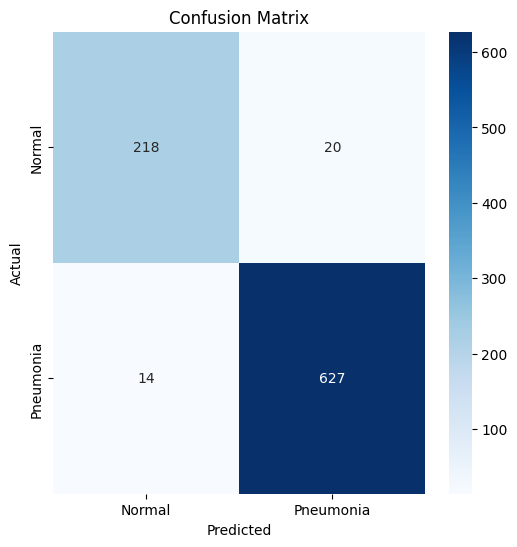

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_label)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Pneumonia"],
            yticklabels=["Normal","Pneumonia"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_true,y_pred_label))

auc = roc_auc_score(y_true,y_pred)
print("ROC AUC:",auc)

              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93       238
         1.0       0.97      0.98      0.97       641

    accuracy                           0.96       879
   macro avg       0.95      0.95      0.95       879
weighted avg       0.96      0.96      0.96       879

ROC AUC: 0.9605035461922679


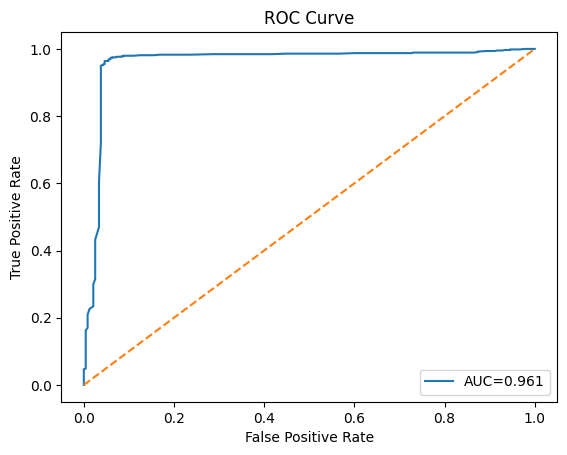

In [ ]:
fpr,tpr,_ = roc_curve(y_true,y_pred)

plt.plot(fpr,tpr,label="AUC="+str(round(auc,3)))
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [ ]:
boot = []

for i in range(1000):

    idx = np.random.choice(len(y_true),len(y_true))

    if len(np.unique(y_true[idx]))<2:
        continue

    boot.append(roc_auc_score(y_true[idx],y_pred[idx]))

low = np.percentile(boot,2.5)
high = np.percentile(boot,97.5)

print("AUC 95% CI:",low,high)

AUC 95% CI: 0.9403709805252852 0.9779952418606339


In [ ]:
def gradcam(model, img):

    last_conv_layer = None

    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer.name
            break

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer).output, model.output[0]]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


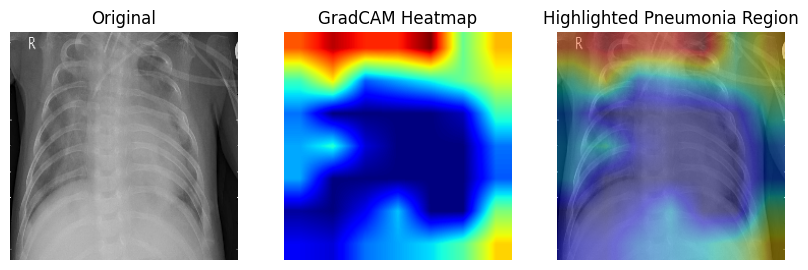

Prediction confidence: 0.5723


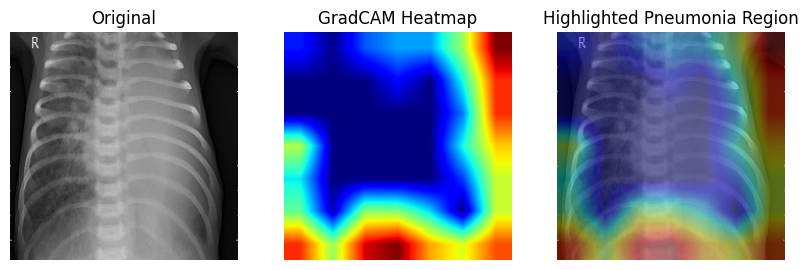

Prediction confidence: 0.5723


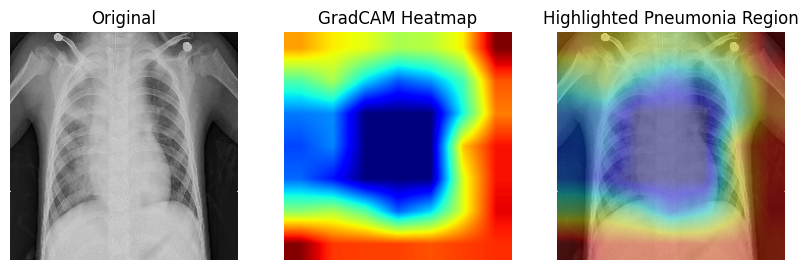

Prediction confidence: 0.589


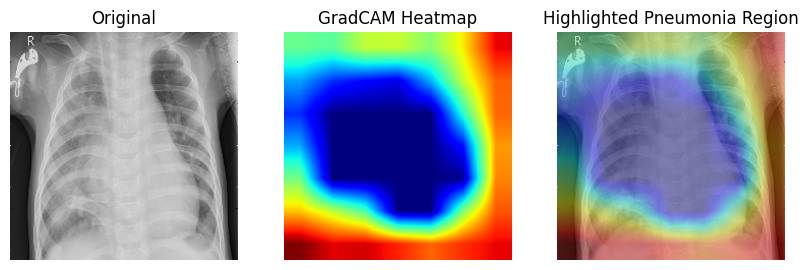

Prediction confidence: 0.5723


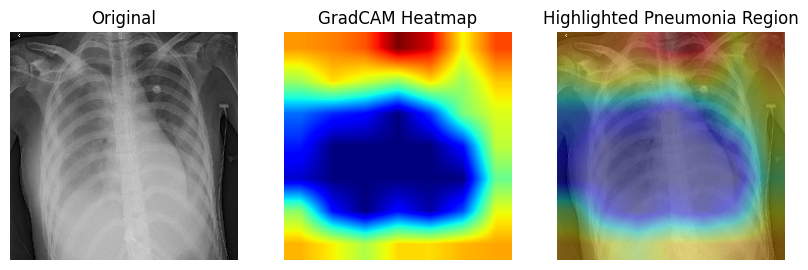

Prediction confidence: 0.5723


In [ ]:
for images, labels in test_ds.take(1):

    preds, _ = model.predict(images)

    for i in range(5):

        img = images[i].numpy()

        cam = gradcam(model, images[i][None,...])

        cam = np.squeeze(cam)
        cam = cv2.resize(cam.astype("float32"), (224,224))

        plt.figure(figsize=(10,4))

        plt.subplot(1,3,1)
        plt.imshow(img)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(cam, cmap="jet")
        plt.title("GradCAM Heatmap")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(img)
        plt.imshow(cam, cmap="jet", alpha=0.4)
        plt.title("Highlighted Pneumonia Region")
        plt.axis("off")

        plt.show()

        print("Prediction confidence:", preds[i][0])

In [ ]:
def gradcam_pp(model, img):

    last_conv_layer = model.get_layer("top_conv")

    grad_model = tf.keras.models.Model(
        model.inputs,
        [last_conv_layer.output, model.output[0]]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    conv_outputs = conv_outputs[0]
    grads = grads[0]

    weights = tf.reduce_mean(grads, axis=(0,1))

    cam = tf.reduce_sum(weights * conv_outputs, axis=-1)

    cam = tf.maximum(cam, 0)
    cam /= (tf.reduce_max(cam) + 1e-8)

    return cam.numpy()

In [ ]:
def lung_mask(image):

    gray = cv2.cvtColor((image*255).astype("uint8"), cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray,(5,5),0)

    _,thresh = cv2.threshold(
        blur,0,255,
        cv2.THRESH_BINARY+cv2.THRESH_OTSU
    )

    mask = cv2.morphologyEx(
        thresh,
        cv2.MORPH_CLOSE,
        np.ones((7,7),np.uint8)
    )

    mask = cv2.resize(mask,(224,224))

    return mask/255.0

In [ ]:
cam = cam * lung_mask(img)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


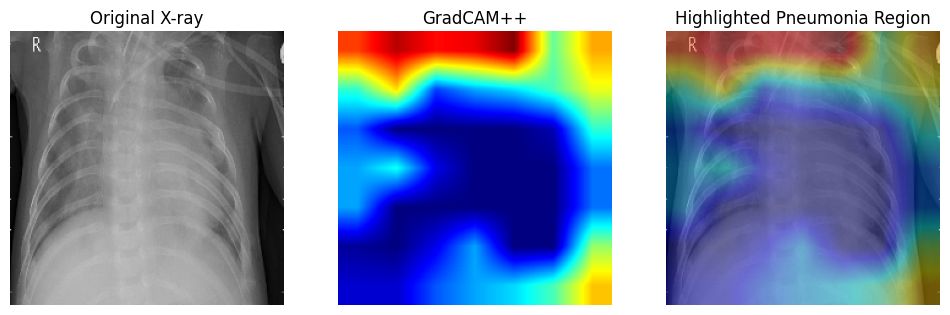

Prediction confidence: 0.572265625


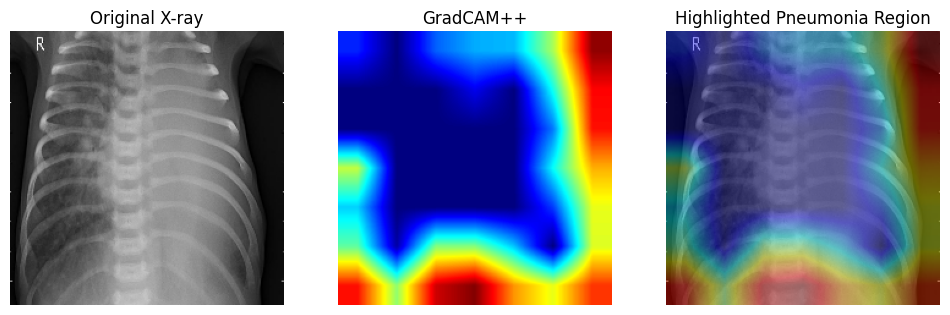

Prediction confidence: 0.572265625


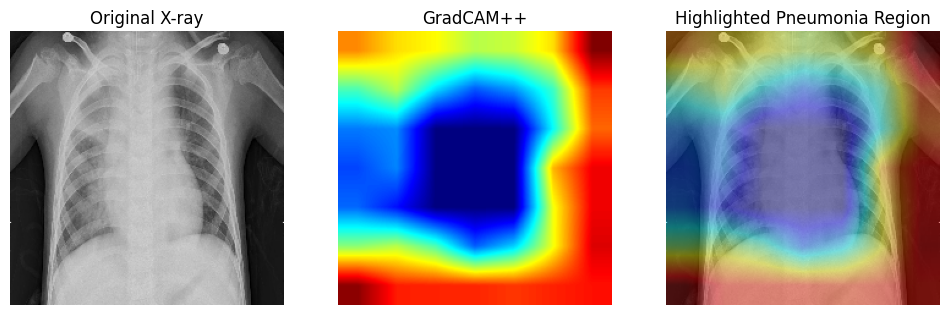

Prediction confidence: 0.5888671875


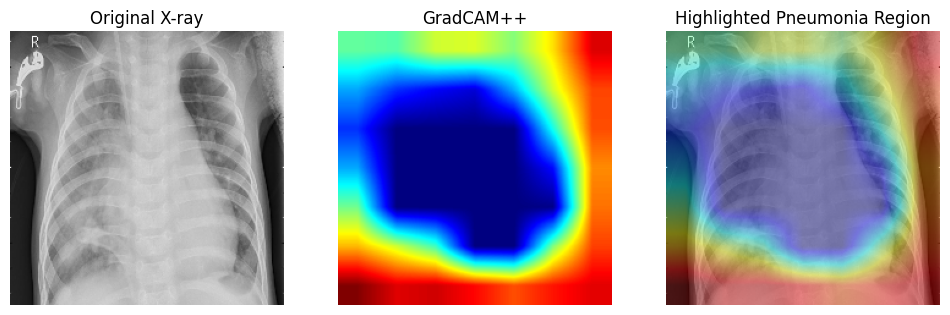

Prediction confidence: 0.572265625


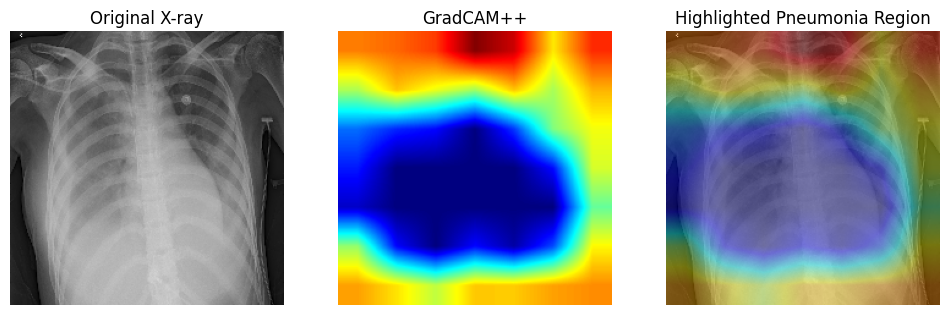

Prediction confidence: 0.572265625


In [ ]:
for images, labels in test_ds.take(1):

    preds,_ = model.predict(images)

    for i in range(5):

        img = images[i].numpy()

        cam = gradcam_pp(model, images[i][None,...])

        cam = np.array(cam)

        if cam.ndim > 2:
            cam = np.squeeze(cam)

        cam = cam.astype("float32")

        cam = cv2.resize(cam, (224,224))

        heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

        overlay = heatmap*0.4 + img*255*0.6
        overlay = overlay.astype("uint8")

        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.imshow(img)
        plt.title("Original X-ray")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(heatmap)
        plt.title("GradCAM++")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(overlay)
        plt.title("Highlighted Pneumonia Region")
        plt.axis("off")

        plt.show()

        print("Prediction confidence:", float(preds[i][0]))

In [ ]:
!pip install -q langchain langchain-community langchain-huggingface faiss-cpu sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 30.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.7/502.7 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [ ]:
medical_docs = [
"""
Pneumonia Treatment Guidelines

Mild Pneumonia:
First line antibiotic: Amoxicillin.

Moderate Pneumonia:
Amoxicillin + Azithromycin.

Severe Pneumonia:
Ceftriaxone + Azithromycin.

Hospitalization required when:
• oxygen saturation < 92%
• severe respiratory distress
• dehydration
""",

"""
Pneumonia Symptoms:
• cough
• fever
• chest pain
• shortness of breath

Radiology findings:
• lung opacity
• consolidation
• patchy infiltrates
"""
]

In [ ]:
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.schema import Document

docs = [Document(page_content=text) for text in medical_docs]

embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vector_db = FAISS.from_documents(docs, embedding_model)

ModuleNotFoundError: No module named 'langchain.schema'